In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read CSV file
df = pd.read_csv('statistics_by_xyz.csv')

# Display basic information about the data
print("Data shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

import scipy.stats as stats
overall_confidence=0.95
number_solution=len(df)
confidence_per_solution=1-(1-overall_confidence)/number_solution
print(confidence_per_solution)
confidence_per_objective=1-(1-confidence_per_solution)/2
print(confidence_per_objective)
z_score=np.abs(stats.norm.ppf((1-confidence_per_objective)/2))

total_cost_mean=df['total_cost_mean'].tolist()
total_cost_se=df['total_cost_se'].tolist()
deviation_mean=df['deviation_mean'].tolist()
deviation_se=df['deviation_se'].tolist()
total_cost_mean=np.array(total_cost_mean)
total_cost_se=np.array(total_cost_se)
deviation_mean=np.array(deviation_mean)
deviation_se=np.array(deviation_se)
total_cost_lower=total_cost_mean-z_score*total_cost_se
total_cost_upper=total_cost_mean+z_score*total_cost_se
deviation_lower=deviation_mean-z_score*deviation_se
deviation_upper=deviation_mean+z_score*deviation_se
LB_list=np.array([-total_cost_upper,deviation_lower])
LB_list=np.transpose(LB_list)
UB_list=np.array([-total_cost_lower,deviation_upper])
UB_list=np.transpose(UB_list)
solution=np.array(df[['x','y','z']])

Lip_CST=np.array([2230,1240,2240])



Data shape: (217, 8)

Column names:
['x', 'y', 'z', 'total_cost_mean', 'total_cost_se', 'deviation_mean', 'deviation_se', 'total_cost_n']

First 5 rows:


,x,y,z,total_cost_mean,total_cost_se,deviation_mean,deviation_se,total_cost_n
0,0.0,0.0,0.00,5429.447819,6.453317,1418.955556,7.032387,900
1,0.0,0.0,0.25,5913.641591,7.924198,910.977778,8.161988,600
2,0.0,0.0,0.50,6328.973016,7.936002,614.126667,4.680350,600
3,0.0,0.0,0.75,6678.182096,7.939688,758.164444,8.656314,600
4,0.0,0.0,1.00,6977.142430,7.904701,1119.668889,9.348826,600


0.9997695852534563
0.9998847926267281


Index(['x', 'y', 'z', 'total_cost_mean', 'total_cost_se', 'deviation_mean',
       'deviation_se', 'total_cost_n'],
      dtype='str')


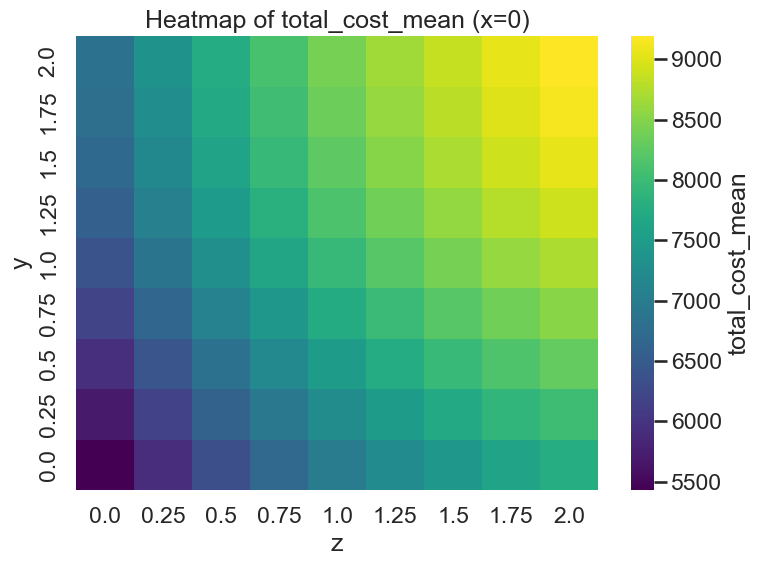

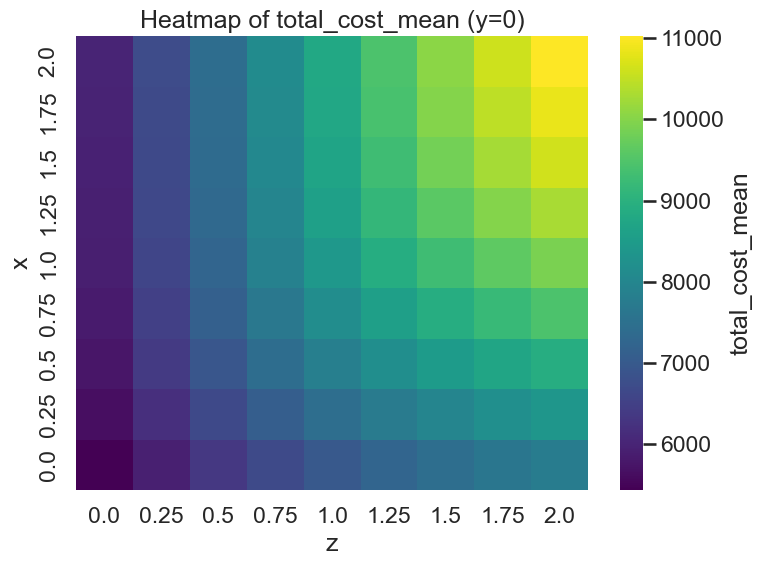

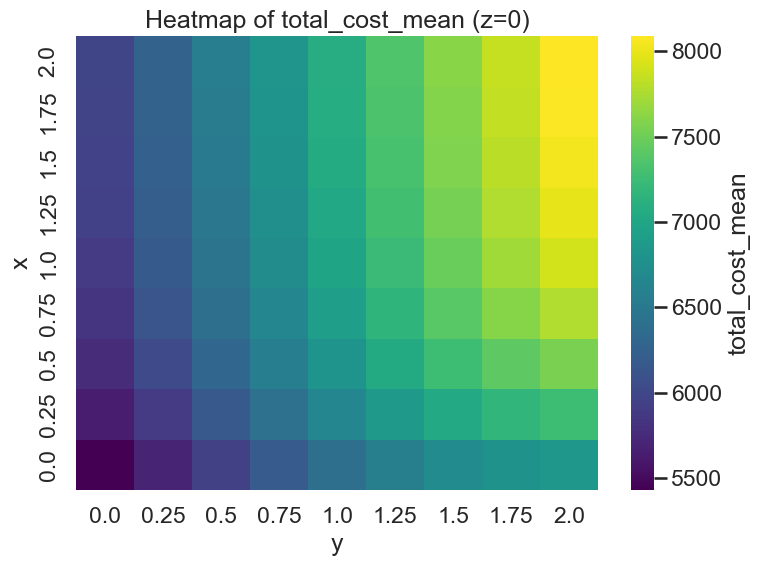

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the uploaded file
df = pd.read_csv('statistics_by_xyz.csv')
print(df.columns)

# Keep only the needed columns
cols = ["x", "y", "z", "total_cost_mean"]
df = df[cols]

# Unified plotting style
sns.set_context("talk")
sns.set_style("whitegrid")

# Three slice cases: x=0, y=0, z=0
slices = {
    "x=0": df[df["x"] == 0],
    "y=0": df[df["y"] == 0],
    "z=0": df[df["z"] == 0],
}

# Plotting
for label, sdf in slices.items():
    if label == "x=0":
        grid = sdf.pivot_table(index="y", columns="z", values="total_cost_mean", aggfunc="mean")
        xlabel, ylabel = "z", "y"
    elif label == "y=0":
        grid = sdf.pivot_table(index="x", columns="z", values="total_cost_mean", aggfunc="mean")
        xlabel, ylabel = "z", "x"
    else:  # z=0
        grid = sdf.pivot_table(index="x", columns="y", values="total_cost_mean", aggfunc="mean")
        xlabel, ylabel = "y", "x"

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(grid, cmap="viridis", cbar_kws={"label": "total_cost_mean"})
    ax.invert_yaxis()
    plt.title(f"Heatmap of total_cost_mean ({label})")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


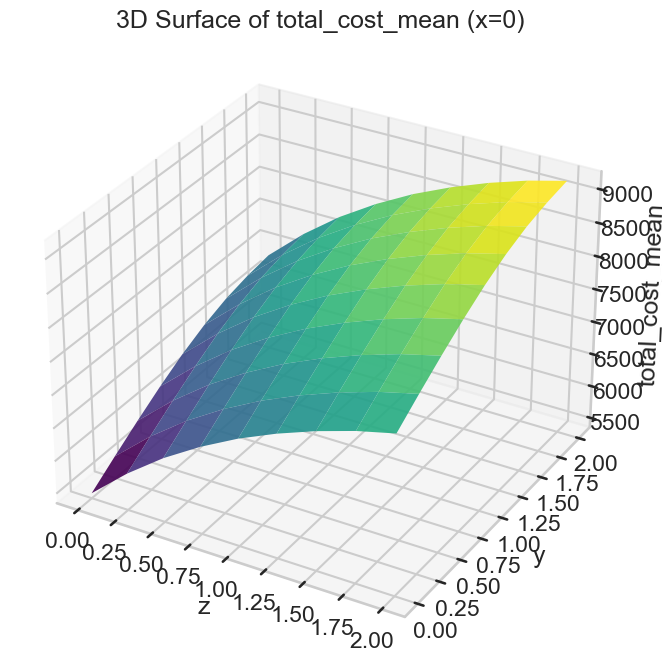

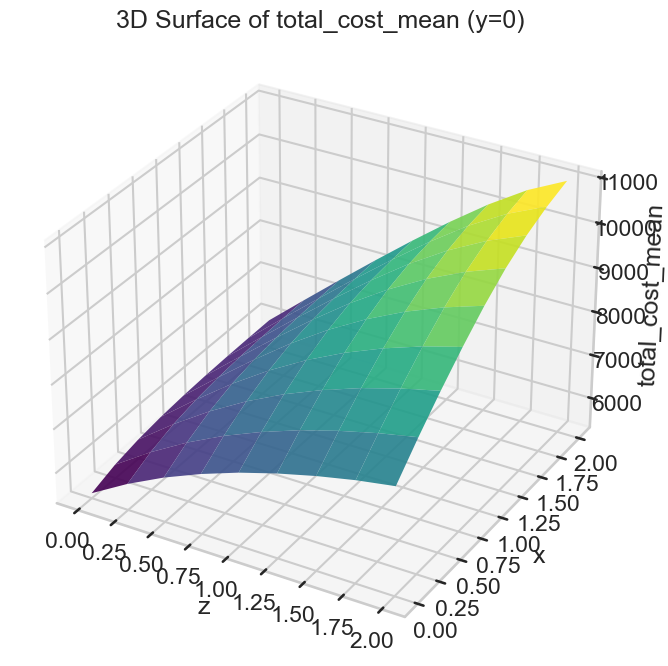

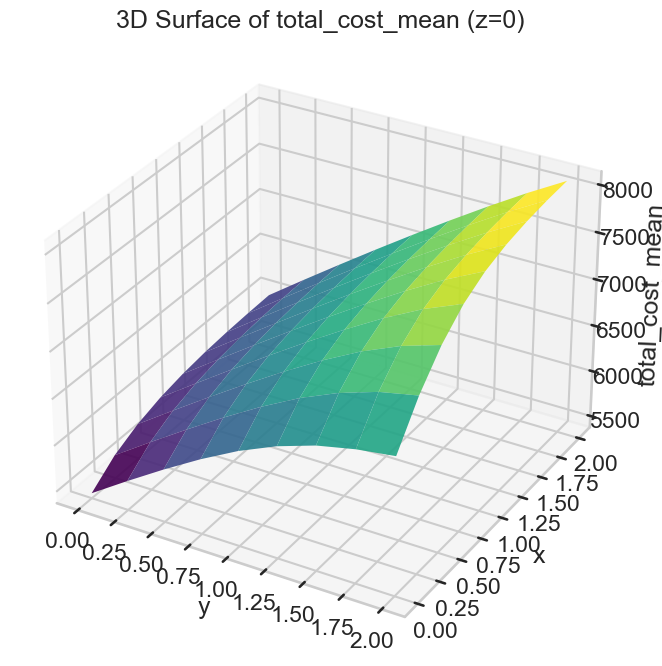

In [3]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

# Three slices: x=0, y=0, z=0
slices = {
    "x=0": df[df["x"] == 0],
    "y=0": df[df["y"] == 0],
    "z=0": df[df["z"] == 0],
}

for label, sdf in slices.items():
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    if label == "x=0":
        X, Y = np.meshgrid(sorted(sdf["z"].unique()), sorted(sdf["y"].unique()))
        Z = sdf.pivot_table(index="y", columns="z", values="total_cost_mean").values
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor="none", alpha=0.9)
        ax.set_xlabel("z")
        ax.set_ylabel("y")
    elif label == "y=0":
        X, Y = np.meshgrid(sorted(sdf["z"].unique()), sorted(sdf["x"].unique()))
        Z = sdf.pivot_table(index="x", columns="z", values="total_cost_mean").values
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor="none", alpha=0.9)
        ax.set_xlabel("z")
        ax.set_ylabel("x")
    else:  # z=0
        X, Y = np.meshgrid(sorted(sdf["y"].unique()), sorted(sdf["x"].unique()))
        Z = sdf.pivot_table(index="x", columns="y", values="total_cost_mean").values
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor="none", alpha=0.9)
        ax.set_xlabel("y")
        ax.set_ylabel("x")

    ax.set_zlabel("total_cost_mean")
    ax.set_title(f"3D Surface of total_cost_mean ({label})")
    plt.tight_layout()
    plt.show()


Index(['x', 'y', 'z', 'total_cost_mean', 'total_cost_se', 'deviation_mean',
       'deviation_se', 'total_cost_n'],
      dtype='str')


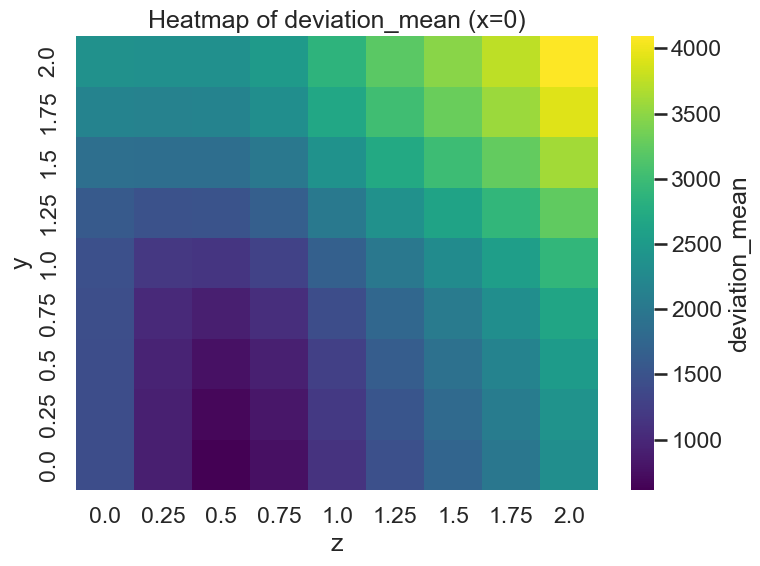

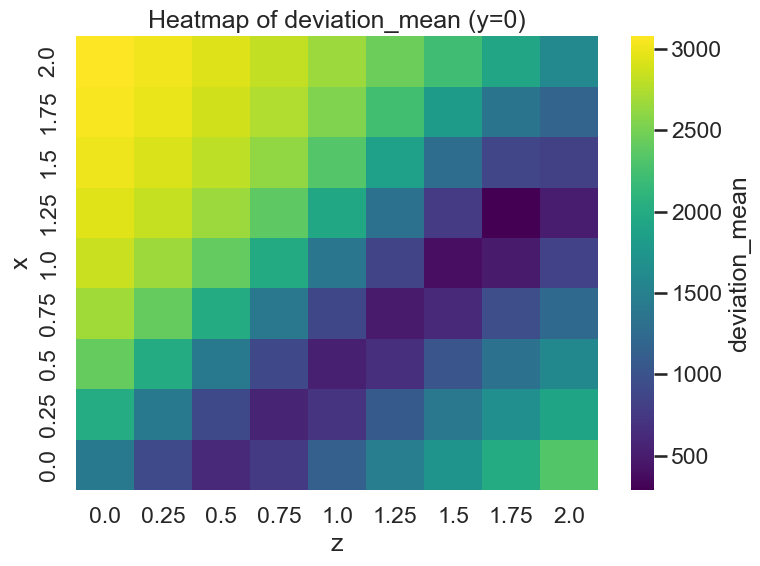

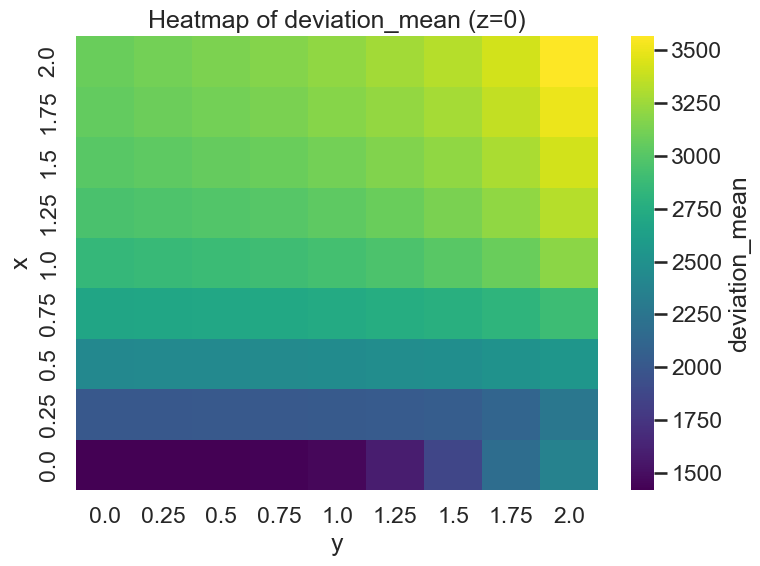

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the uploaded file
df = pd.read_csv('statistics_by_xyz.csv')
print(df.columns)

# Keep only the needed columns
cols = ["x", "y", "z", "deviation_mean"]
df = df[cols]

# Unified plotting style
sns.set_context("talk")
sns.set_style("whitegrid")

# Three slice cases: x=0, y=0, z=0
slices = {
    "x=0": df[df["x"] == 0],
    "y=0": df[df["y"] == 0],
    "z=0": df[df["z"] == 0],
}

# Plotting
for label, sdf in slices.items():
    if label == "x=0":
        grid = sdf.pivot_table(index="y", columns="z", values="deviation_mean", aggfunc="mean")
        xlabel, ylabel = "z", "y"
    elif label == "y=0":
        grid = sdf.pivot_table(index="x", columns="z", values="deviation_mean", aggfunc="mean")
        xlabel, ylabel = "z", "x"
    else:  # z=0
        grid = sdf.pivot_table(index="x", columns="y", values="deviation_mean", aggfunc="mean")
        xlabel, ylabel = "y", "x"

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(grid, cmap="viridis", cbar_kws={"label": "deviation_mean"})
    ax.invert_yaxis()
    plt.title(f"Heatmap of deviation_mean ({label})")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


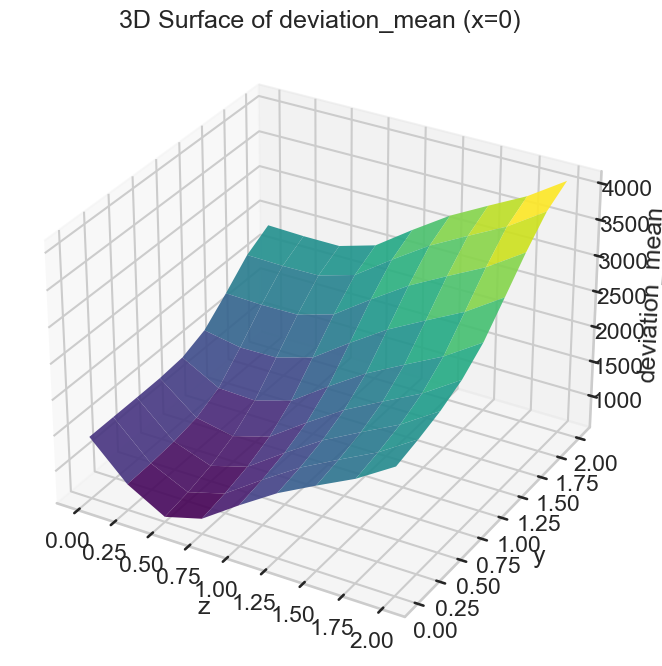

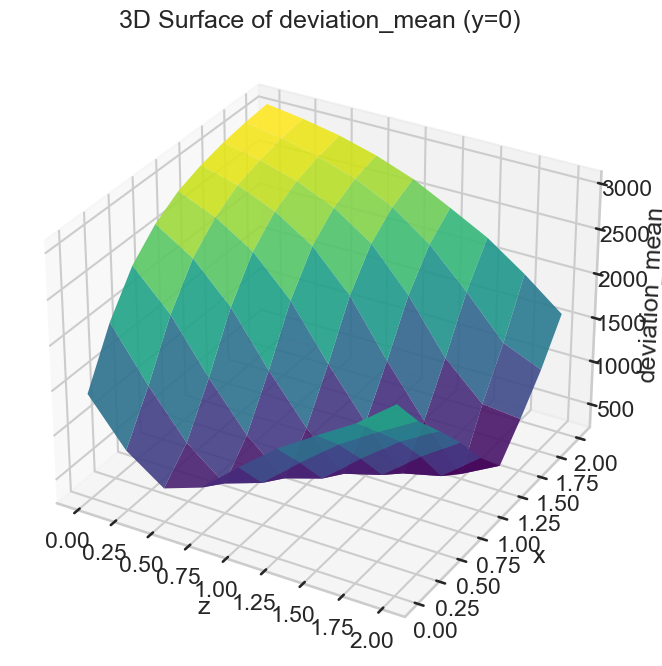

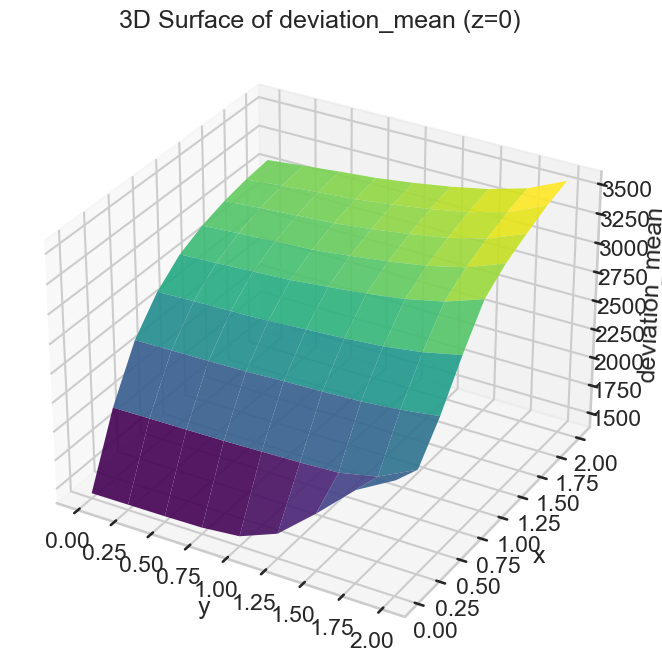

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

# Three slices: x=0, y=0, z=0
slices = {
    "x=0": df[df["x"] == 0],
    "y=0": df[df["y"] == 0],
    "z=0": df[df["z"] == 0],
}

for label, sdf in slices.items():
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    if label == "x=0":
        X, Y = np.meshgrid(sorted(sdf["z"].unique()), sorted(sdf["y"].unique()))
        Z = sdf.pivot_table(index="y", columns="z", values="deviation_mean").values
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor="none", alpha=0.9)
        ax.set_xlabel("z")
        ax.set_ylabel("y")
    elif label == "y=0":
        X, Y = np.meshgrid(sorted(sdf["z"].unique()), sorted(sdf["x"].unique()))
        Z = sdf.pivot_table(index="x", columns="z", values="deviation_mean").values
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor="none", alpha=0.9)
        ax.set_xlabel("z")
        ax.set_ylabel("x")
    else:  # z=0
        X, Y = np.meshgrid(sorted(sdf["y"].unique()), sorted(sdf["x"].unique()))
        Z = sdf.pivot_table(index="x", columns="y", values="deviation_mean").values
        ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor="none", alpha=0.9)
        ax.set_xlabel("y")
        ax.set_ylabel("x")
        
    #ax.view_init(elev=35, azim=45)
    ax.set_zlabel("deviation_mean")
    ax.set_title(f"3D Surface of deviation_mean ({label})")
    plt.tight_layout()
    plt.show()


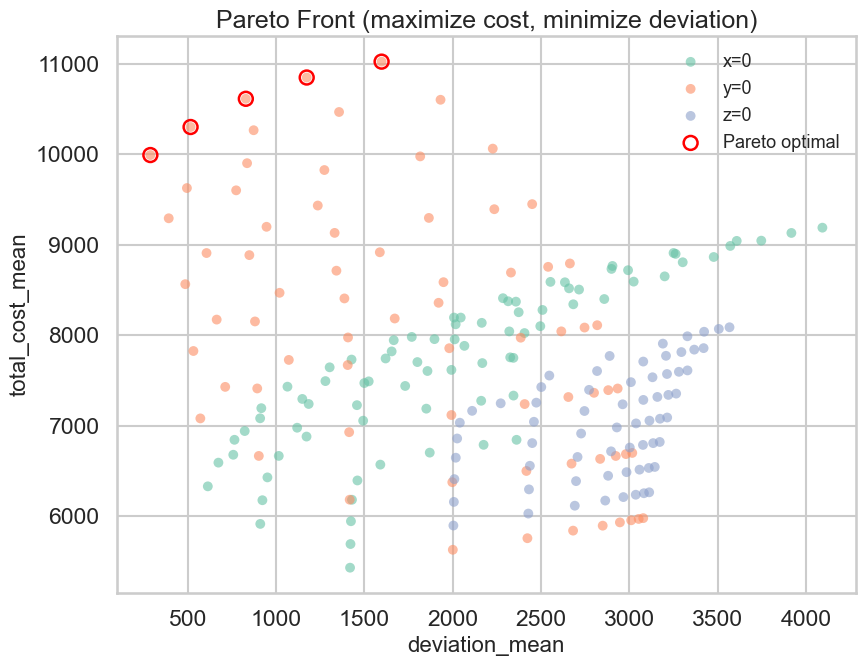

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data
df = pd.read_csv("statistics_by_xyz.csv")

# Keep only the columns we care about
cols = ["x", "y", "z", "total_cost_mean", "deviation_mean"]
df = df[cols]

# === Step 1: Pareto frontier determination ===
# Objective: maximize cost, minimize deviation
points = df[["deviation_mean", "total_cost_mean"]].values
is_pareto = np.ones(points.shape[0], dtype=bool)

for i, (dev_i, cost_i) in enumerate(points):
    # If there exists a point j such that dev_j <= dev_i and cost_j >= cost_i, with at least one strict,
    # then i is dominated (not Pareto optimal)
    if np.any(
        (points[:, 0] <= dev_i) & (points[:, 1] >= cost_i) &
        ((points[:, 0] < dev_i) | (points[:, 1] > cost_i))
    ):
        is_pareto[i] = False

# Mark Pareto optimal points
df["pareto_optimal"] = is_pareto

# === Step 2: Identify plane ===
def identify_plane(row, tol=1e-9):
    if abs(row["x"]) < tol:
        return "x=0"
    elif abs(row["y"]) < tol:
        return "y=0"
    elif abs(row["z"]) < tol:
        return "z=0"
    else:
        return "other"

df["plane"] = df.apply(identify_plane, axis=1)

# === Step 3: Plotting ===
palette = {"x=0": "#66c2a5", "y=0": "#fc8d62", "z=0": "#8da0cb"}

plt.figure(figsize=(9, 7))
for plane, subdf in df.groupby("plane"):
    plt.scatter(
        subdf["deviation_mean"],
        subdf["total_cost_mean"],
        label=plane,
        color=palette.get(plane, "gray"),
        alpha=0.6,
        s=50,
        edgecolors="none"
    )

# Pareto optimal points: red outer ring
pareto_points = df[df["pareto_optimal"]]
plt.scatter(
    pareto_points["deviation_mean"],
    pareto_points["total_cost_mean"],
    facecolors="none",
    edgecolors="red",
    linewidths=1.8,
    s=100,
    label="Pareto optimal"
)

# Axis labels and styling
plt.xlabel("deviation_mean", fontsize=16)
plt.ylabel("total_cost_mean", fontsize=16)
plt.title("Pareto Front (maximize cost, minimize deviation)", fontsize=18)
plt.legend(frameon=False, fontsize=13)
plt.tight_layout()
plt.show()
